# Stress Test Results Analysis
Reads `stress_results.json` — cumulative memory (Jupyter-style, no GC between cells).

In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

RESULTS_PATH = pathlib.Path("stress_results.json")

with RESULTS_PATH.open() as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f"Loaded {len(df)} phases from {RESULTS_PATH}")
df

Matplotlib is building the font cache; this may take a moment.


Loaded 17 phases from stress_results.json


,label,elapsed_s,mem_start_mb,mem_end_mb,mem_delta_mb,cpu_pct
0,db_avg_score_by_dept,0.186,143.1,143.1,0.0,0.0
1,db_course_stats_join5,0.176,143.1,143.1,0.0,0.0
2,db_top_students_cte,0.179,143.1,143.1,0.0,0.0
3,db_assignment_difficulty,0.023,143.1,143.2,0.1,0.0
4,db_window_func_running_avg,0.227,143.2,170.1,26.9,70.3
5,pandas_load_100k_join,1.728,198.1,345.6,147.4,90.7
6,pandas_feature_engineering,0.433,345.6,347.0,1.4,87.7
7,pandas_groupby_agg,0.505,347.0,351.5,4.5,96.8
8,pandas_pivot_table,0.117,351.5,351.5,0.1,101.3
9,pandas_corr_matrix,0.235,351.5,351.5,0.0,97.8


In [4]:
df.describe()

,elapsed_s,mem_start_mb,mem_end_mb,mem_delta_mb,cpu_pct
count,17.000000,17.000000,17.000000,17.000000,17.000000
mean,0.384471,287.564706,299.435294,11.864706,152.958824
std,0.511062,104.374637,101.298371,35.718779,195.416155
min,0.023000,143.100000,143.100000,0.000000,0.000000
25%,0.117000,143.200000,170.100000,0.100000,70.300000
50%,0.186000,351.500000,351.500000,0.300000,97.800000
75%,0.396000,370.500000,370.800000,1.400000,116.900000
max,1.728000,391.000000,392.300000,147.400000,664.400000


## Summary Table

In [2]:
summary = df[[
    "label", "elapsed_s", "mem_start_mb", "mem_end_mb", "mem_delta_mb", "cpu_pct"
]].copy()

# Colour mem_delta: green near 0, red at high
def colour_delta(val):
    r = min(255, int(val * 2))
    g = max(0, 200 - int(val * 2))
    return f"background-color: rgb({r},{g},80)"

base_mb  = df["mem_start_mb"].iloc[0]
peak_mb  = df["mem_end_mb"].max()
total_s  = df["elapsed_s"].sum()
peak_cpu = df["cpu_pct"].max()

print(f"Base RSS : {base_mb:.0f} MB")
print(f"Peak RSS : {peak_mb:.0f} MB  (+{peak_mb - base_mb:.0f} MB)")
print(f"Total time : {total_s:.3f} s")
print(f"Peak CPU : {peak_cpu:.1f}%")
print()

summary.style.applymap(colour_delta, subset=["mem_delta_mb"]) \
             .format({
                 "elapsed_s":    "{:.3f}",
                 "mem_start_mb": "{:.1f}",
                 "mem_end_mb":   "{:.1f}",
                 "mem_delta_mb": "{:+.1f}",
                 "cpu_pct":      "{:.1f}",
             })

Base RSS : 143 MB
Peak RSS : 392 MB  (+249 MB)
Total time : 6.536 s
Peak CPU : 664.4%



/var/folders/_6/7v804cr97wv8xwh601kqx5tw0000gn/T/ipykernel_71569/1710352940.py:22: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  summary.style.applymap(colour_delta, subset=["mem_delta_mb"]) \


,label,elapsed_s,mem_start_mb,mem_end_mb,mem_delta_mb,cpu_pct
0,db_avg_score_by_dept,0.186,143.1,143.1,+0.0,0.0
1,db_course_stats_join5,0.176,143.1,143.1,+0.0,0.0
2,db_top_students_cte,0.179,143.1,143.1,+0.0,0.0
3,db_assignment_difficulty,0.023,143.1,143.2,+0.1,0.0
4,db_window_func_running_avg,0.227,143.2,170.1,+26.9,70.3
5,pandas_load_100k_join,1.728,198.1,345.6,+147.4,90.7
6,pandas_feature_engineering,0.433,345.6,347.0,+1.4,87.7
7,pandas_groupby_agg,0.505,347.0,351.5,+4.5,96.8
8,pandas_pivot_table,0.117,351.5,351.5,+0.1,101.3
9,pandas_corr_matrix,0.235,351.5,351.5,+0.0,97.8


## Memory Staircase — cumulative RSS across phases
Shows how RSS climbs and never drops back (Jupyter kernel behaviour).

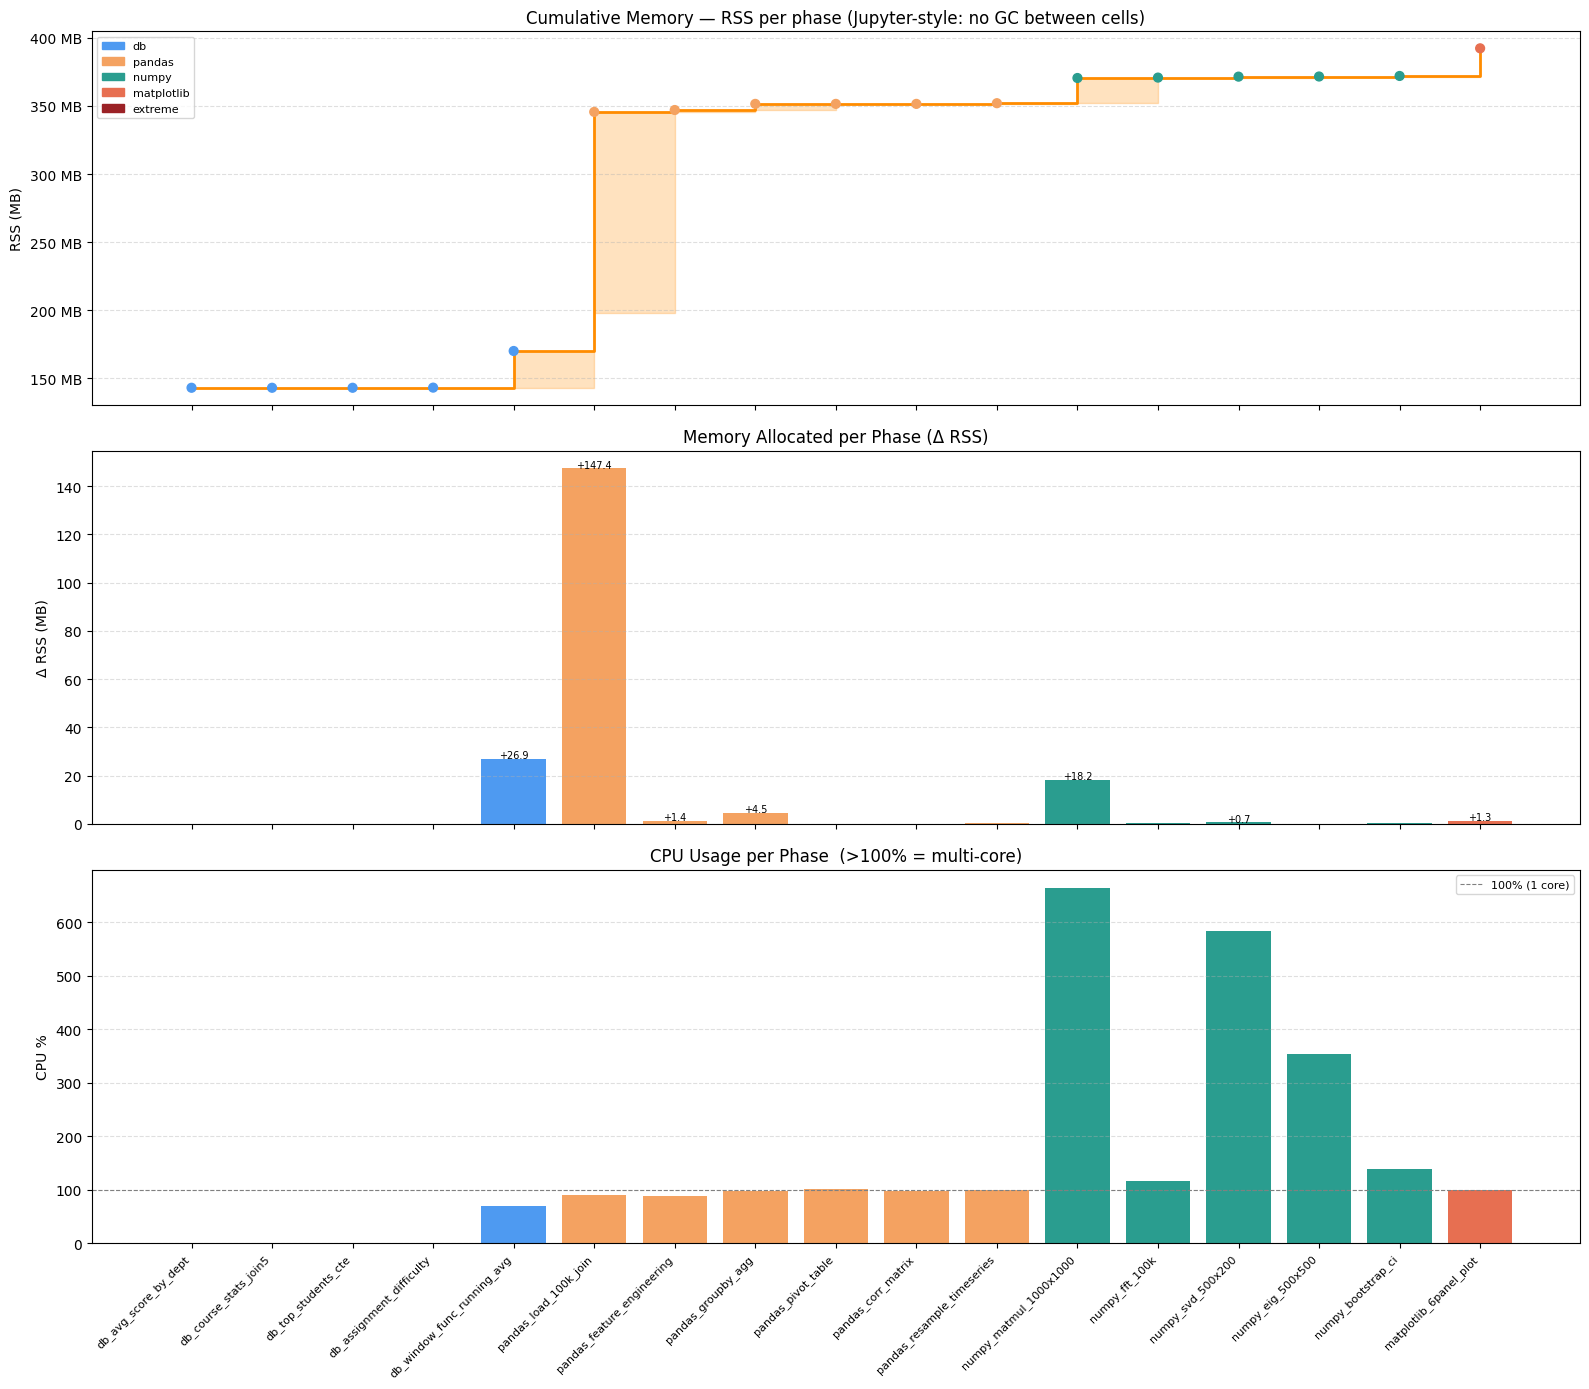

Saved → analysis_chart.png


In [3]:
labels = df["label"].tolist()
mem_start = df["mem_start_mb"].tolist()
mem_end   = df["mem_end_mb"].tolist()

# Scenario colour bands
SCENARIO_COLOURS = {
    "db":          "#4e9af1",
    "pandas":      "#f4a261",
    "numpy":       "#2a9d8f",
    "matplotlib":  "#e76f51",
    "extreme":     "#9b2226",
}

def scenario_of(lbl):
    for k in SCENARIO_COLOURS:
        if lbl.startswith(k):
            return k
    return "other"

colours = [SCENARIO_COLOURS.get(scenario_of(l), "#888") for l in labels]

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
x = np.arange(len(labels))

# ── Panel 1: RSS staircase ────────────────────────────────────────────────────
ax = axes[0]
ax.step(x, mem_end, where="post", color="darkorange", linewidth=2, label="RSS end")
ax.fill_between(x, mem_start, mem_end, step="post", alpha=0.25, color="darkorange")
ax.scatter(x, mem_end, c=colours, zorder=5, s=40)
ax.set_ylabel("RSS (MB)")
ax.set_title("Cumulative Memory — RSS per phase (Jupyter-style: no GC between cells)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f} MB"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
# legend for scenarios
from matplotlib.patches import Patch
handles = [Patch(color=c, label=k) for k, c in SCENARIO_COLOURS.items()]
ax.legend(handles=handles, loc="upper left", fontsize=8)

# ── Panel 2: mem_delta per phase ──────────────────────────────────────────────
ax2 = axes[1]
bars = ax2.bar(x, df["mem_delta_mb"], color=colours)
ax2.set_ylabel("Δ RSS (MB)")
ax2.set_title("Memory Allocated per Phase (Δ RSS)")
for i, v in enumerate(df["mem_delta_mb"]):
    if abs(v) > 0.5:
        ax2.text(i, v + 0.3 if v >= 0 else v - 2, f"{v:+.1f}",
                 ha="center", fontsize=7)
ax2.grid(axis="y", linestyle="--", alpha=0.4)

# ── Panel 3: CPU% ─────────────────────────────────────────────────────────────
ax3 = axes[2]
ax3.bar(x, df["cpu_pct"], color=colours)
ax3.axhline(100, color="gray", linestyle="--", linewidth=0.8, label="100% (1 core)")
ax3.set_ylabel("CPU %")
ax3.set_title("CPU Usage per Phase  (>100% = multi-core)")
ax3.set_xticks(x)
ax3.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax3.legend(fontsize=8)
ax3.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("analysis_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → analysis_chart.png")

## Elapsed Time per Phase

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.barh(labels[::-1], df["elapsed_s"][::-1], color=colours[::-1])
ax.set_xlabel("Elapsed (s)")
ax.set_title("Elapsed Time per Phase")
for i, (v, lbl) in enumerate(zip(df["elapsed_s"][::-1], labels[::-1])):
    ax.text(v + 0.01, i, f"{v:.3f}s", va="center", fontsize=8)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Scenario-level Rollup

In [ ]:
df["scenario"] = df["label"].apply(scenario_of)

rollup = df.groupby("scenario", sort=False).agg(
    phases       =("label",        "count"),
    total_time_s =("elapsed_s",    "sum"),
    total_mem_mb =("mem_delta_mb", "sum"),
    peak_cpu_pct =("cpu_pct",      "max"),
    rss_entry_mb =("mem_start_mb", "first"),
    rss_exit_mb  =("mem_end_mb",   "last"),
).reset_index()

rollup["net_rss_mb"] = rollup["rss_exit_mb"] - rollup["rss_entry_mb"]

rollup.style.format({
    "total_time_s": "{:.3f}",
    "total_mem_mb": "{:+.1f}",
    "peak_cpu_pct": "{:.1f}",
    "rss_entry_mb": "{:.0f}",
    "rss_exit_mb":  "{:.0f}",
    "net_rss_mb":   "{:+.0f}",
})